In [ ]:
자연어처리(NLP) 기초 & HuggingFace 입문

이 실습에서는 자연어처리의 기본 개념부터 HuggingFace 라이브러리를 활용한 실전 응용까지 단계적으로 학습합니다.
학습 목표
단계 	주제 	설명
1 	형태소 분석 	한국어 형태소 분석기(KoNLPy)를 사용한 텍스트 분석
2 	빈도 분석 	단어/형태소 빈도 계산 및 시각화
3 	Tokenizer 기초 	HuggingFace Tokenizer의 작동 원리 이해
4 	Pretrained Model 	BERT 기반 모델 로딩 및 Embedding 추출
5 	텍스트 분류 	간단한 감성 분류 모델 구현
환경 정보

    Runtime: Google Colab (T4 GPU)
    Python: 3.10+
    주요 라이브러리: transformers, datasets, torch, konlpy

실습 데이터

    한국어 뉴스 기사 및 리뷰 데이터
    네이버 영화 리뷰 감성 분류 데이터(NSMC)

In [ ]:
Part 1: 형태소 분석 (Morphological Analysis)
한국어는 교착어로서, 단어가 어근과 접사의 결합으로 이루어집니다. 형태소 분석은 문장을 의미 있는 최소 단위(형태소)로 분리하는 과정입니다.
형태소 분석기 	특징
Okt 	Twitter 기반, 빠른 속도
Komoran 	자체 사전, 안정적
Kkma 	꼬꼬마, 정확한 분석
Hannanum 	한나눔, KAIST 개발


In [ ]:
# 실습 데이터 정의
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식q합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

print("실습 데이터:")
for i, text in enumerate(sample_texts, 1):
    print(f"{i}. {text}")

In [ ]:
Q1. KoNLPy의 Okt 형태소 분석기를 사용하여 문장을 형태소로 분리하세요.

    조건1: Okt 형태소 분석기를 초기화할 것

    조건2: morphs() 메서드로 첫 번째 샘플 텍스트의 형태소를 추출할 것

    조건3: pos() 메서드로 품사 태깅 결과도 함께 출력할 것
Q2. 여러 형태소 분석기의 결과를 비교하세요.

    조건1: Okt, Komoran, Kkma 세 가지 분석기를 사용할 것

    조건2: 동일한 문장에 대해 각 분석기의 결과를 비교할 것

    조건3: 결과를 표 형태로 정리하여 출력할 것
Q3. 명사만 추출하는 함수를 작성하세요.

    조건1: nouns() 메서드를 활용할 것

    조건2: 모든 샘플 텍스트에서 명사를 추출하여 리스트로 반환할 것

    조건3: 1글자 명사는 제외할 것 (의미 없는 단어 필터링)


In [2]:
!pip install transformers konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.3 MB/s eta 0:00:00
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 11.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 12.4 MB/s eta 0:00:0000:0100:01
   ━━━

In [3]:
# === Q1 ===
from konlpy.tag import Okt

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# 조건1: Okt 형태소 분석기 초기화
okt = Okt()

# 조건2: morphs() 메서드로 첫 번째 샘플 텍스트의 형태소 추출
first_text = sample_texts[0]
morphs_result = okt.morphs(first_text)

# 조건3: pos() 메서드로 품사 태깅 결과 출력
pos_result = okt.pos(first_text)

# 결과 출력
print("=== 원문 ===")
print(first_text)
print()

print("=== morphs() 결과 (형태소 분리) ===")
print(morphs_result)
print()

print("=== pos() 결과 (품사 태깅) ===")
print(pos_result)
print()

# join=True 옵션으로 보기 쉽게 출력
print("=== pos() 결과 (join=True) ===")
print(okt.pos(first_text, join=True))

=== 원문 ===
인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.

=== morphs() 결과 (형태소 분리) ===
['인공', '지능', '기술', '이', '빠르게', '발전', '하면서', '우리', '일상', '에', '많은', '변화', '가', '생기', '고', '있습니다', '.']

=== pos() 결과 (품사 태깅) ===
[('인공', 'Noun'), ('지능', 'Noun'), ('기술', 'Noun'), ('이', 'Josa'), ('빠르게', 'Adjective'), ('발전', 'Noun'), ('하면서', 'Verb'), ('우리', 'Noun'), ('일상', 'Noun'), ('에', 'Josa'), ('많은', 'Adjective'), ('변화', 'Noun'), ('가', 'Josa'), ('생기', 'Noun'), ('고', 'Josa'), ('있습니다', 'Adjective'), ('.', 'Punctuation')]

=== pos() 결과 (join=True) ===
['인공/Noun', '지능/Noun', '기술/Noun', '이/Josa', '빠르게/Adjective', '발전/Noun', '하면서/Verb', '우리/Noun', '일상/Noun', '에/Josa', '많은/Adjective', '변화/Noun', '가/Josa', '생기/Noun', '고/Josa', '있습니다/Adjective', './Punctuation']


In [4]:
# === Q2 ===
from konlpy.tag import Okt, Komoran, Kkma

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# 분석기 초기화
okt = Okt()
komoran = Komoran()
kkma = Kkma()

# 첫 번째 텍스트
first_text = sample_texts[0]

# 각 분석기로 형태소 분석 (pos: 품사 태깅 포함)
okt_result = okt.pos(first_text)
komoran_result = komoran.pos(first_text)
kkma_result = kkma.pos(first_text)

# 표 출력을 위한 데이터 정리
print("=" * 80)
print(f"원문: {first_text}")
print("=" * 80)
print()

# 헤더 출력
print(f"{'순서':<4} | {'Okt':<20} | {'Komoran':<20} | {'Kkma':<20}")
print("-" * 80)

# 최대 길이 확인
max_len = max(len(okt_result), len(komoran_result), len(kkma_result))

# 각 행 출력
for i in range(max_len):
    okt_item = f"{okt_result[i][0]}/{okt_result[i][1]}" if i < len(okt_result) else ""
    komoran_item = f"{komoran_result[i][0]}/{komoran_result[i][1]}" if i < len(komoran_result) else ""
    kkma_item = f"{kkma_result[i][0]}/{kkma_result[i][1]}" if i < len(kkma_result) else ""
    print(f"{i+1:<4} | {okt_item:<20} | {komoran_item:<20} | {kkma_item:<20}")

print("-" * 80)
print()

# 간단한 요약 정보
print("=== 분석기별 형태소 개수 ===")
print(f"Okt:     {len(okt_result)}개")
print(f"Komoran: {len(komoran_result)}개")
print(f"Kkma:    {len(kkma_result)}개")

원문: 인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.

순서   | Okt                  | Komoran              | Kkma                
--------------------------------------------------------------------------------
1    | 인공/Noun              | 인공지능/NNP             | 인공지능/NNG            
2    | 지능/Noun              | 기술/NNG               | 기술/NNG              
3    | 기술/Noun              | 이/JKS                | 이/JKS               
4    | 이/Josa               | 빠르/VA                | 빠르/VA               
5    | 빠르게/Adjective        | 게/EC                 | 게/ECD               
6    | 발전/Noun              | 발전/NNG               | 발전/NNG              
7    | 하면서/Verb             | 하/XSV                | 하/XSV               
8    | 우리/Noun              | 면서/EC                | 면서/ECE              
9    | 일상/Noun              | 우리/NP                | 우리/NP               
10   | 에/Josa               | 일상/NNG               | 일상/NNG              
11   | 많은/Adjective         | 에/JKB                | 에/JK

In [5]:
# === Q3 ===
from konlpy.tag import Okt

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# 조건1: Okt 형태소 분석기 초기화
okt = Okt()

# 조건2, 3을 만족하는 명사 추출 함수
def extract_nouns(texts, min_length=2):
    """
    여러 텍스트에서 명사만 추출하여 리스트로 반환하는 함수
    
    Args:
        texts: 텍스트 리스트
        min_length: 최소 글자 수 (기본값: 2, 1글자 명사 필터링)
    
    Returns:
        조건에 맞는 명사 리스트
    """
    all_nouns = []
    
    for text in texts:
        # 조건2: nouns() 메서드로 명사 추출
        nouns = okt.nouns(text)
        
        # 조건3: 1글자 명사 제외
        filtered_nouns = [noun for noun in nouns if len(noun) >= min_length]
        
        all_nouns.extend(filtered_nouns)
    
    return all_nouns

# 함수 실행
result = extract_nouns(sample_texts)

# 결과 출력
print("=== 추출된 명사 리스트 ===")
print(result)
print()

print(f"=== 총 {len(result)}개의 명사 추출 ===")
print()

# 중복 제거 후 출력
unique_nouns = list(set(result))
print("=== 중복 제거된 명사 ===")
print(sorted(unique_nouns))
print(f"\n총 {len(unique_nouns)}개의 고유 명사")

=== 추출된 명사 리스트 ===
['인공', '지능', '기술', '발전', '우리', '일상', '변화', '생기', '자연어', '처리', '컴퓨터', '인간', '언어', '이해', '기술', '러닝', '모델', '대량', '데이터', '학습', '패턴', '인식', '트랜스포머', '아키텍처', '현대', '핵심', '기술', '자리', '사전', '학습', '모델', '자연어', '처리', '성능', '크게', '향상']

=== 총 36개의 명사 추출 ===

=== 중복 제거된 명사 ===
['기술', '대량', '데이터', '러닝', '모델', '발전', '변화', '사전', '생기', '성능', '아키텍처', '언어', '우리', '이해', '인간', '인공', '인식', '일상', '자리', '자연어', '지능', '처리', '컴퓨터', '크게', '트랜스포머', '패턴', '학습', '핵심', '향상', '현대']

총 30개의 고유 명사


In [ ]:
Part 2: 빈도 분석 (Frequency Analysis)

텍스트에서 자주 등장하는 단어/형태소를 분석하여 핵심 키워드를 파악합니다.

Q4. 명사 빈도를 계산하고 상위 10개를 출력하세요.

    조건1: Python의 collections.Counter를 사용할 것

    조건2: Q3에서 만든 함수로 명사를 추출할 것

    조건3: 빈도수 기준 상위 10개 명사를 출력할 것
 # A4.
from collections import Counter

# 더 많은 샘플 데이터 (빈도 분석을 위해)
extended_texts = sample_texts + [
    "자연어처리 기술은 챗봇, 번역, 요약 등 다양한 분야에 활용됩니다.",
    "딥러닝 기반의 언어 모델은 문맥을 이해하는 능력이 뛰어납니다.",
    "데이터 전처리는 자연어처리 파이프라인의 첫 번째 단계입니다.",
    "토큰화는 텍스트를 작은 단위로 분리하는 과정입니다.",
    "임베딩은 단어를 벡터 공간에 표현하는 기술입니다.",
    "어텐션 메커니즘은 입력의 중요한 부분에 집중하는 기술입니다.",
    "사전학습 언어 모델은 대규모 코퍼스로 학습됩니다.",
    "파인튜닝은 사전학습 모델을 특정 태스크에 맞게 조정합니다."
]

# 명사 추출 및 빈도 계산

Q5. 단어 빈도를 막대 그래프로 시각화하세요.

    조건1: matplotlib을 사용할 것

    조건2: 상위 10개 단어를 수평 막대 그래프로 표시할 것

    조건3: 한글 폰트 설정을 포함할 것 (Colab 환경)
# Colab 한글 폰트 설정 해당 셀 실행 후, "런타임" -> "세션 다시 시작 및 모두 실행" 필요!
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [6]:
# === Q4 ===
from konlpy.tag import Okt
from collections import Counter

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# Okt 형태소 분석기 초기화
okt = Okt()

# 조건2: Q3에서 만든 명사 추출 함수 (1글자 명사 제외)
def extract_nouns(texts, min_length=2):
    """
    여러 텍스트에서 명사만 추출하여 리스트로 반환하는 함수
    
    Args:
        texts: 텍스트 리스트
        min_length: 최소 글자 수 (기본값: 2)
    
    Returns:
        조건에 맞는 명사 리스트
    """
    all_nouns = []
    
    for text in texts:
        # 조건1: nouns() 메서드로 명사 추출
        nouns = okt.nouns(text)
        
        # 조건3: 1글자 명사 제외
        filtered_nouns = [noun for noun in nouns if len(noun) >= min_length]
        
        all_nouns.extend(filtered_nouns)
    
    return all_nouns

# 명사 추출
nouns_list = extract_nouns(sample_texts)

# 조건1: collections.Counter로 빈도수 계산
noun_counts = Counter(nouns_list)

# 조건3: 빈도수 기준 상위 10개 명사 출력
top_10_nouns = noun_counts.most_common(10)

print("=== 명사 빈도수 상위 10개 ===")
print(f"{'순위':<4} | {'명사':<12} | {'빈도수':<6}")
print("-" * 30)

for rank, (noun, count) in enumerate(top_10_nouns, 1):
    print(f"{rank:<4} | {noun:<12} | {count:<6}")

print("-" * 30)
print(f"\n총 추출된 명사 수: {len(nouns_list)}개")
print(f"고유 명사 수: {len(noun_counts)}개")

=== 명사 빈도수 상위 10개 ===
순위   | 명사           | 빈도수   
------------------------------
1    | 기술           | 3     
2    | 자연어          | 2     
3    | 처리           | 2     
4    | 모델           | 2     
5    | 학습           | 2     
6    | 인공           | 1     
7    | 지능           | 1     
8    | 발전           | 1     
9    | 우리           | 1     
10   | 일상           | 1     
------------------------------

총 추출된 명사 수: 36개
고유 명사 수: 30개


In [ ]:
!apt-get install -y fonts-nanum

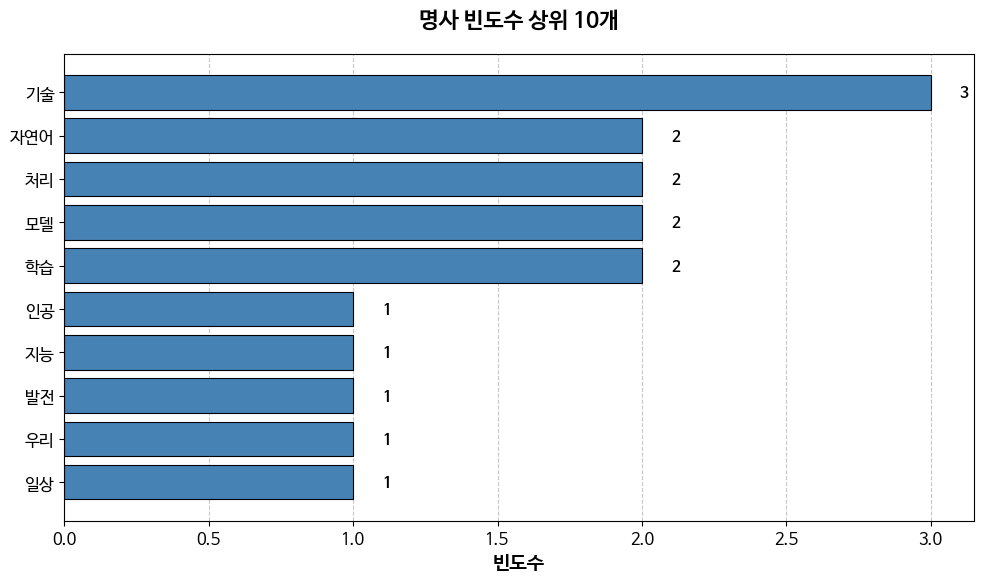

In [3]:
# === Q5 ===
from konlpy.tag import Okt
from collections import Counter
import matplotlib.pyplot as plt

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# Okt 형태소 분석기 초기화
okt = Okt()

# 명사 추출 함수 (Q3 코드 재사용)
def extract_nouns(texts, min_length=2):
    all_nouns = []
    for text in texts:
        nouns = okt.nouns(text)
        filtered_nouns = [noun for noun in nouns if len(noun) >= min_length]
        all_nouns.extend(filtered_nouns)
    return all_nouns

# 명사 추출 및 빈도수 계산
nouns_list = extract_nouns(sample_texts)
noun_counts = Counter(nouns_list)
top_10 = noun_counts.most_common(10)

# 데이터 분리
labels = [item[0] for item in top_10]
counts = [item[1] for item in top_10]

# 조건3: fonts-nanum 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 조건1, 2: matplotlib으로 수평 막대 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 수평 막대 그래프 (barh)
bars = ax.barh(labels, counts, color='steelblue', edgecolor='black', linewidth=0.8)

# 그래프 꾸미기
ax.set_xlabel('빈도수', fontsize=14, fontweight='bold')
ax.set_title('명사 빈도수 상위 10개', fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()  # 1위가 위로 오도록

# 막대 위에 빈도수 표시
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=11, fontweight='bold')

# 그리드 추가 (x축만)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
Q6. 워드클라우드를 생성하세요.

    조건1: wordcloud 라이브러리를 사용할 것

    조건2: 한글 폰트를 설정할 것

    조건3: 배경색은 흰색, 최대 단어 수는 50개로 설정할 것


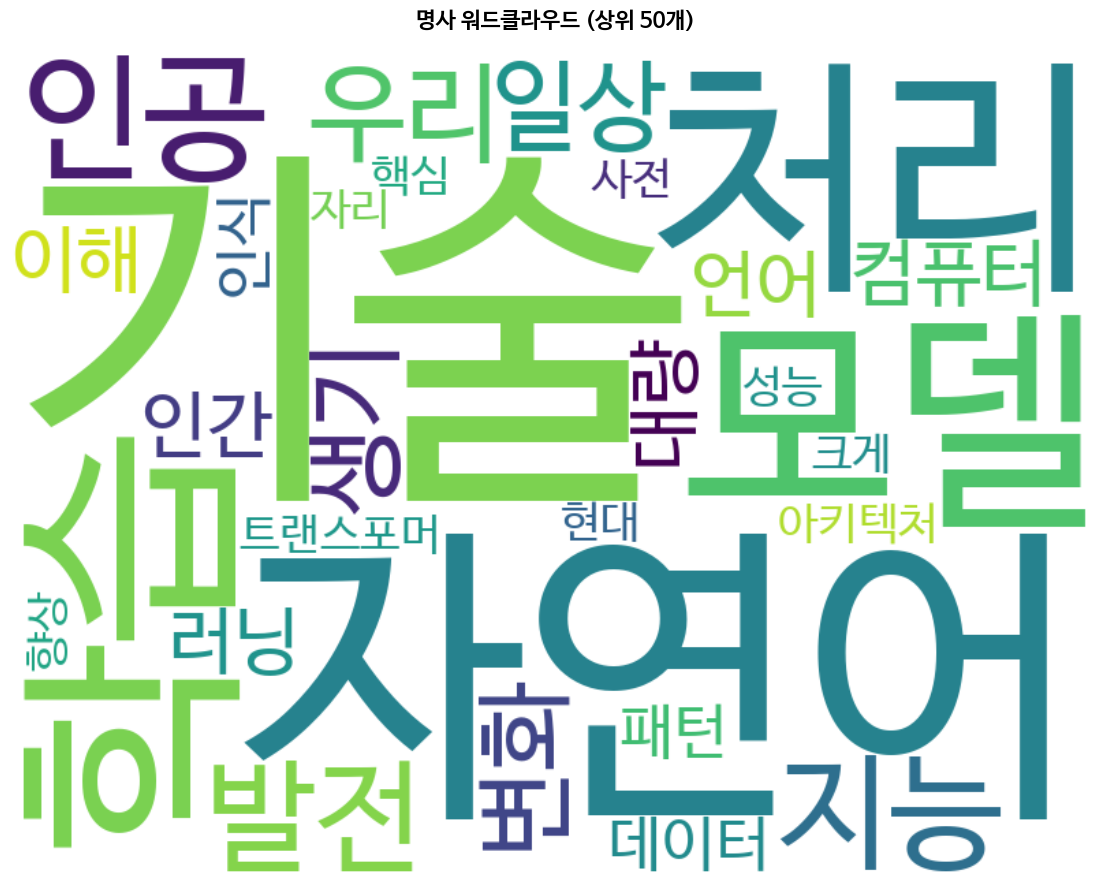

워드클라우드가 'wordcloud_nouns.png'로 저장되었습니다.


In [7]:
# === Q6 ===
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 샘플 텍스트
sample_texts = [
    "인공지능 기술이 빠르게 발전하면서 우리 일상에 많은 변화가 생기고 있습니다.",
    "자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습하여 패턴을 인식합니다.",
    "트랜스포머 아키텍처는 현대 NLP의 핵심 기술로 자리잡았습니다.",
    "BERT와 GPT 같은 사전학습 모델이 자연어처리 성능을 크게 향상시켰습니다."
]

# Okt 형태소 분석기 초기화
okt = Okt()

# 명사 추출 함수 (기존 코드 재사용)
def extract_nouns(texts, min_length=2):
    all_nouns = []
    for text in texts:
        nouns = okt.nouns(text)
        filtered_nouns = [noun for noun in nouns if len(noun) >= min_length]
        all_nouns.extend(filtered_nouns)
    return all_nouns

# 명사 추출 및 빈도수 계산
nouns_list = extract_nouns(sample_texts)
noun_counts = Counter(nouns_list)

# 조건1: wordcloud 라이브러리 사용
# 조건2: 한글 폰트 설정 (fonts-nanum)
# 조건3: 배경색 흰색, 최대 단어 수 50개
wordcloud = WordCloud(
    font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',  # 조건2: 한글 폰트
    background_color='white',      # 조건3: 배경색 흰색
    max_words=50,                  # 조건3: 최대 단어 수 50개
    width=800,
    height=600,
    colormap='viridis',            # 컬러맵 설정 (선택사항)
    contour_width=1,
    contour_color='steelblue'
)

# 빈도수 딕셔너리를 문자열로 변환 (WordCloud 입력 형식)
text_data = ' '.join(nouns_list)
wordcloud.generate(text_data)

# 워드클라우드 시각화
plt.figure(figsize=(12, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 제거
plt.title('명사 워드클라우드 (상위 50개)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 워드클라우드를 이미지 파일로 저장 (선택사항)
wordcloud.to_file('wordcloud_nouns.png')
print("워드클라우드가 'wordcloud_nouns.png'로 저장되었습니다.")

In [ ]:
Part 3: Tokenizer 기초

Tokenizer는 텍스트를 모델이 이해할 수 있는 토큰 단위로 변환합니다.
Tokenization 방식 	설명
Word-level 	단어 단위 분리
Character-level 	문자 단위 분리
Subword (BPE, WordPiece) 	단어와 문자 사이의 최적 단위

Q7. HuggingFace Tokenizer의 기본 사용법을 익히세요.

    조건1: transformers의 AutoTokenizer를 사용할 것

    조건2: klue/bert-base 모델의 토크나이저를 로드할 것

    조건3: 샘플 문장의 토큰화 결과(input_ids, tokens)를 확인할 것

Q8. 배치 토큰화와 패딩을 적용하세요.

    조건1: 여러 문장을 한 번에 토큰화할 것

    조건2: padding=True, truncation=True를 설정할 것

    조건3: max_length=64로 제한할 것

    조건4: return_tensors="pt"로 PyTorch 텐서를 반환할 것
# A8.
# 배치 토큰화 수행
batch_sentences = [
    "자연어처리는 인공지능의 핵심 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습합니다.",
    "BERT는 양방향 문맥을 이해합니다."
]

# 토큰화 수행

Q9. 특수 토큰과 어텐션 마스크를 이해하세요.

    조건1: [CLS], [SEP], [PAD] 토큰의 역할을 설명할 것

    조건2: attention_mask의 의미를 확인할 것

    조건3: 토큰 ID를 다시 텍스트로 디코딩해볼 것

# A9.
# 특수 토큰 확인


# 어텐션 마스크 시각화


# 디코딩 (토큰 ID -> 텍스트)





In [10]:
# === Q7 ===
from transformers import AutoTokenizer

# 조건2: klue/bert-base 모델의 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 조건3: 샘플 문장 토크나이징
sample_text = "저는 한국어를 공부하고 있습니다."

# 토크나이징 수행 (input_ids, attention_mask 등 포함)
encoded = tokenizer(sample_text, return_tensors="pt")

# input_ids 추출
input_ids = encoded["input_ids"][0].tolist()

# 실제 토큰 리스트로 변환
tokens = tokenizer.convert_ids_to_tokens(input_ids)

# 결과 확인
print("=== 샘플 문장 ===")
print(f"원문: {sample_text}\n")

print("=== input_ids ===")
print(input_ids)
print()

print("=== 토큰 리스트 ===")
print(tokens)
print()

# 각 토큰과 ID 매핑 확인
print("=== 토큰-ID 매핑 ===")
for token, token_id in zip(tokens, input_ids):
    print(f"{token_id:5d} : {token}")

=== 샘플 문장 ===
원문: 저는 한국어를 공부하고 있습니다.

=== input_ids ===
[2, 1535, 2259, 9187, 2138, 4244, 19521, 1513, 2219, 3606, 18, 3]

=== 토큰 리스트 ===
['[CLS]', '저', '##는', '한국어', '##를', '공부', '##하고', '있', '##습', '##니다', '.', '[SEP]']

=== 토큰-ID 매핑 ===
    2 : [CLS]
 1535 : 저
 2259 : ##는
 9187 : 한국어
 2138 : ##를
 4244 : 공부
19521 : ##하고
 1513 : 있
 2219 : ##습
 3606 : ##니다
   18 : .
    3 : [SEP]


In [13]:
# === Q8 ===
from transformers import AutoTokenizer
import torch

# 1. 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 2. 여러 문장 (배치) 준비
sentences = [
    "자연어처리는 인공지능의 핵심 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습합니다.",
    "BERT는 양방향 문맥을 이해합니다."
]

# 3. 배치 토크나이징 (조건 1~4 모두 적용)
encoded_batch = tokenizer(
    sentences,
    padding=True,        # 조건2: 배치 내 가장 긴 문장에 맞춰 패딩
    truncation=True,     # 조건2: max_length 초과 시 잘라내기
    max_length=64,       # 조건3: 최대 길이 제한
    return_tensors="pt"  # 조건4: PyTorch 텐서 반환
)

# 4. 결과 확인
print("=== 배치 토크나이징 결과 ===\n")

print(f"문장 개수 (배치 크기): {len(sentences)}")
print(f"input_ids shape: {encoded_batch['input_ids'].shape}")
print(f"attention_mask shape: {encoded_batch['attention_mask'].shape}")
print(f"token_type_ids shape: {encoded_batch['token_type_ids'].shape}\n")

# 각 문장별 토큰 수 확인
print("=== 문장별 토큰 수 (패딩 포함) ===")
for i, (sent, ids, mask) in enumerate(zip(sentences, encoded_batch['input_ids'], encoded_batch['attention_mask'])):
    real_tokens = mask.sum().item()  # 패딩 제외 실제 토큰 수
    print(f"문장 {i+1}: {real_tokens}개 (원문: {sent[:30]}...)")

print("\n=== 첫 번째 문장 상세 확인 ===")
print(f"원문: {sentences[0]}")
print(f"input_ids: {encoded_batch['input_ids'][0].tolist()}")
print(f"tokens: {tokenizer.convert_ids_to_tokens(encoded_batch['input_ids'][0].tolist())}")
print(f"attention_mask: {encoded_batch['attention_mask'][0].tolist()}")

=== 배치 토크나이징 결과 ===

문장 개수 (배치 크기): 3
input_ids shape: torch.Size([3, 14])
attention_mask shape: torch.Size([3, 14])
token_type_ids shape: torch.Size([3, 14])

=== 문장별 토큰 수 (패딩 포함) ===
문장 1: 12개 (원문: 자연어처리는 인공지능의 핵심 기술입니다....)
문장 2: 14개 (원문: 딥러닝 모델은 대량의 데이터로 학습합니다....)
문장 3: 12개 (원문: BERT는 양방향 문맥을 이해합니다....)

=== 첫 번째 문장 상세 확인 ===
원문: 자연어처리는 인공지능의 핵심 기술입니다.
input_ids: [2, 3941, 2051, 20111, 2259, 9128, 2079, 4325, 3726, 12190, 18, 3, 0, 0]
tokens: ['[CLS]', '자연', '##어', '##처리', '##는', '인공지능', '##의', '핵심', '기술', '##입니다', '.', '[SEP]', '[PAD]', '[PAD]']
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


특수 토큰 역할 설명

🔹 [CLS]: 문장의 시작을 표시. 분류(Classification) 작업에서 **문장 전체의 의미를 집약**하는 벡터로 사용됨

🔹 [SEP]: 문장의 끝 또는 문장 간 구분을 표시. 단일 문장은 끝에 1개, 문장 쌍은 사이에 1개 + 끝에 1개 사용

🔹 [PAD]: 배치 내 문장 길이를 맞추기 위한 **패딩 토큰**. 실제 의미가 없으며 attention_mask로 무시됨

attention_mask 의미 및 시각화

📌 attention_mask 의미:
   • 1 = 실제 토큰 (모델이 주의 깊게 봄)
   • 0 = 패딩 토큰 (모델이 무시함)
   • Self-Attention에서 패딩 부분의 가중치를 0으로 만듦

📊 attention_mask 시각화:


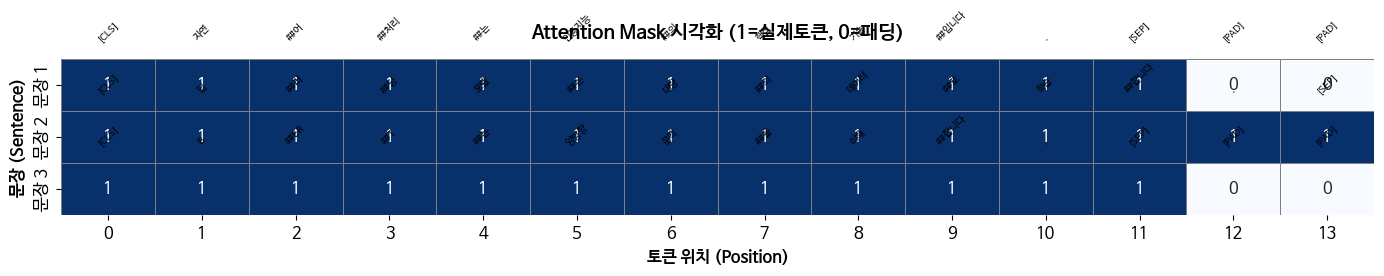


토큰 ID → 텍스트 디코딩

📝 원문 1: 자연어처리는 인공지능의 핵심 기술입니다.
   input_ids: [2, 3941, 2051, 20111, 2259, 9128, 2079, 4325, 3726, 12190, 18, 3, 0, 0]
   tokens: ['[CLS]', '자연', '##어', '##처리', '##는', '인공지능', '##의', '핵심', '기술', '##입니다', '.', '[SEP]', '[PAD]', '[PAD]']
   디코딩 (특수토큰 제거): 자연어처리는 인공지능의 핵심 기술입니다.
   디코딩 (특수토큰 포함): [CLS] 자연어처리는 인공지능의 핵심 기술입니다. [SEP] [PAD] [PAD]

📝 원문 2: 딥러닝 모델은 대량의 데이터로 학습합니다.
   input_ids: [2, 893, 2030, 2944, 4347, 2073, 7679, 2079, 5189, 2200, 4611, 11800, 18, 3]
   tokens: ['[CLS]', '딥', '##러', '##닝', '모델', '##은', '대량', '##의', '데이터', '##로', '학습', '##합니다', '.', '[SEP]']
   디코딩 (특수토큰 제거): 딥러닝 모델은 대량의 데이터로 학습합니다.
   디코딩 (특수토큰 포함): [CLS] 딥러닝 모델은 대량의 데이터로 학습합니다. [SEP]

📝 원문 3: BERT는 양방향 문맥을 이해합니다.
   input_ids: [2, 38, 10646, 2081, 2259, 24133, 22512, 2069, 3923, 11800, 18, 3, 0, 0]
   tokens: ['[CLS]', 'B', '##ER', '##T', '##는', '양방향', '문맥', '##을', '이해', '##합니다', '.', '[SEP]', '[PAD]', '[PAD]']
   디코딩 (특수토큰 제거): BERT는 양방향 문맥을 이해합니다.
   디코딩 (특수토큰 포함): [CLS] BERT는 양방향 문맥을 이해합

In [17]:
# === Q9 ===
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 2. 샘플 문장들
sentences = [
    "자연어처리는 인공지능의 핵심 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습합니다.",
    "BERT는 양방향 문맥을 이해합니다."
]

# 3. 배치 토크나이징
inputs = tokenizer(
    sentences,
    padding=True,
    truncation=True,
    max_length=16,
    return_tensors="pt"
)

# ============================================================
# 조건1: [CLS], [SEP], [PAD] 토큰 역할 설명
# ============================================================
print("=" * 60)
print("특수 토큰 역할 설명")
print("=" * 60)

special_tokens_info = {
    "[CLS]": "문장의 시작을 표시. 분류(Classification) 작업에서 **문장 전체의 의미를 집약**하는 벡터로 사용됨",
    "[SEP]": "문장의 끝 또는 문장 간 구분을 표시. 단일 문장은 끝에 1개, 문장 쌍은 사이에 1개 + 끝에 1개 사용",
    "[PAD]": "배치 내 문장 길이를 맞추기 위한 **패딩 토큰**. 실제 의미가 없으며 attention_mask로 무시됨"
}

for token, desc in special_tokens_info.items():
    print(f"\n🔹 {token}: {desc}")

# ============================================================
# 조건2: attention_mask 의미 설명 및 시각화
# ============================================================
print("\n" + "=" * 60)
print("attention_mask 의미 및 시각화")
print("=" * 60)

print("\n📌 attention_mask 의미:")
print("   • 1 = 실제 토큰 (모델이 주의 깊게 봄)")
print("   • 0 = 패딩 토큰 (모델이 무시함)")
print("   • Self-Attention에서 패딩 부분의 가중치를 0으로 만듦")

print("\n📊 attention_mask 시각화:")

# 시각화 데이터 준비
tokens_list = []
masks_list = []

for i in range(len(sentences)):
    token_ids = inputs["input_ids"][i].tolist()
    mask = inputs["attention_mask"][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    tokens_list.append(tokens)
    masks_list.append(mask)

# 히트맵 생성
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    masks_list,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=range(len(masks_list[0])),
    yticklabels=[f"문장 {i+1}" for i in range(len(sentences))],
    ax=ax,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_xlabel("토큰 위치 (Position)", fontsize=12, fontweight='bold')
ax.set_ylabel("문장 (Sentence)", fontsize=12, fontweight='bold')
ax.set_title("Attention Mask 시각화 (1=실제토큰, 0=패딩)", fontsize=14, fontweight='bold', pad=15)

# 토큰 라벨을 상단에 표시
for i, tokens in enumerate(tokens_list):
    for j, token in enumerate(tokens):
        text = token[:8] if len(token) > 8 else token  # 긴 토큰은 잘라서 표시
        ax.text(j + 0.5, i - 0.3, text, ha='center', va='bottom', fontsize=7, rotation=45)

plt.tight_layout()
plt.savefig("attention_mask_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 조건3: 토큰 ID를 다시 텍스트로 디코딩
# ============================================================
print("\n" + "=" * 60)
print("토큰 ID → 텍스트 디코딩")
print("=" * 60)

for i, sent in enumerate(sentences):
    print(f"\n📝 원문 {i+1}: {sent}")
    
    # input_ids 추출
    token_ids = inputs["input_ids"][i].tolist()
    
    # 토큰 리스트로 변환
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    
    # 다시 텍스트로 디코딩 (디코딩 시 특수 토큰 제거 옵션)
    decoded_text = tokenizer.decode(token_ids, skip_special_tokens=True)
    decoded_with_special = tokenizer.decode(token_ids, skip_special_tokens=False)
    
    print(f"   input_ids: {token_ids}")
    print(f"   tokens: {tokens}")
    print(f"   디코딩 (특수토큰 제거): {decoded_text}")
    print(f"   디코딩 (특수토큰 포함): {decoded_with_special}")

# ============================================================
# 추가: 실제 토큰과 패딩 토큰 구분 표시
# ============================================================
print("\n" + "=" * 60)
print("【추가】실제 토큰 vs 패딩 토큰 상세 분석")
print("=" * 60)

for i in range(len(sentences)):
    token_ids = inputs["input_ids"][i].tolist()
    mask = inputs["attention_mask"][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    
    print(f"\n📄 문장 {i+1}: \"{sentences[i]}\"")
    print("-" * 50)
    print(f"{'위치':<6} {'토큰ID':<8} {'토큰':<12} {'Mask':<6} {'상태'}")
    print("-" * 50)
    
    for pos, (tid, tok, m) in enumerate(zip(token_ids, tokens, mask)):
        status = "✅ 실제" if m == 1 else "❌ 패딩"
        print(f"{pos:<6} {tid:<8} {tok:<12} {m:<6} {status}")

In [ ]:
Part 4: Pretrained Model & Embedding

사전학습된 언어 모델을 로드하고 텍스트 임베딩을 추출합니다.
모델 	설명
BERT 	양방향 인코더 (문맥 이해)
KoBERT, KLUE-BERT 	한국어 특화 BERT
Sentence-BERT 	문장 임베딩에 최적화

Q10. KLUE-BERT 모델을 로드하고 임베딩을 추출하세요.

    조건1: AutoModel로 klue/bert-base 모델을 로드할 것

    조건2: 샘플 문장의 [CLS] 토큰 임베딩을 추출할 것

    조건3: 임베딩 차원을 확인할 것 (BERT-base는 768차원)
Q11. 주어진 문장 간 유사도를 Q10에서 불러온 모델로 임베딩된 벡터에 대해서 계산하세요.

    조건1: 여러 문장의 임베딩을 추출하는 함수를 작성할 것

    조건2: 코사인 유사도를 계산할 것

    조건3: 유사도 행렬을 히트맵으로 시각화할 것
# A11.
# 유사도 비교할 문장들
sentences = [
    "인공지능이 빠르게 발전하고 있습니다.",
    "AI 기술이 급속도로 진화하고 있습니다.",  # 유사
    "오늘 날씨가 매우 좋습니다.",  # 다른 주제
    "머신러닝은 데이터에서 패턴을 학습합니다.",  # 관련 주제
]

# 임베딩 추출 및 유사도 계산

In [19]:
# === Q10 ===
from transformers import AutoTokenizer, AutoModel
import torch

# ============================================================
# 조건1: AutoModel로 klue/bert-base 모델 로드
# ============================================================
print("🔄 모델 로딩 중...")

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# BERT 모델 로드 (가중치 포함)
model = AutoModel.from_pretrained("klue/bert-base")

# 평가 모드로 설정 (드롭아웃 비활성화)
model.eval()

print("✅ 모델 로딩 완료!\n")

# ============================================================
# 샘플 문장 준비 및 토크나이징
# ============================================================
sentences = [
    "한국어 자연어 처리가 재미있습니다.",
    "BERT 모델로 임베딩을 추출합니다."
]

# 토크나이징 (패딩, 잘라내기 적용)
inputs = tokenizer(
    sentences,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

print(f"📄 샘플 문장: {sentences}")
print(f"📊 입력 텐서 shape: {inputs['input_ids'].shape}\n")

# ============================================================
# 조건2: [CLS] 토큰 임베딩 추출
# ============================================================
print("=" * 60)
print("[CLS] 토큰 임베딩 추출")
print("=" * 60)

# 그래디언트 계산 비활성화 (메모리 절약)
with torch.no_grad():
    # 모델 순전파
    outputs = model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )
    
    # outputs.last_hidden_state: (배치크기, 시퀀스길이, 768)
    # [CLS]는 항상 인덱스 0에 위치
    cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (배치크기, 768)

print(f"\n✅ [CLS] 임베딩 추출 완료!")
print(f"   - 전체 출력 shape: {outputs.last_hidden_state.shape}")
print(f"   - [CLS] 임베딩 shape: {cls_embeddings.shape}")

# 각 문장의 [CLS] 임베딩 확인
for i, sent in enumerate(sentences):
    print(f"\n📝 문장 {i+1}: \"{sent}\"")
    print(f"   [CLS] 벡터 (앞 10개): {cls_embeddings[i][:10].tolist()}")
    print(f"   [CLS] 벡터 norm: {torch.norm(cls_embeddings[i]).item():.4f}")

# ============================================================
# 조건3: 임베딩 차원 확인 (BERT-base는 768차원)
# ============================================================
print("\n" + "=" * 60)
print("임베딩 차원 확인")
print("=" * 60)

# BERT 모델 설정에서 hidden_size 확인
hidden_size = model.config.hidden_size
num_layers = model.config.num_hidden_layers
num_attention_heads = model.config.num_attention_heads

print(f"\n🔧 KLUE-BERT-base 모델 스펙:")
print(f"   - 임베딩 차원 (hidden_size): {hidden_size}차원 ✅")
print(f"   - 인코더 레이어 수: {num_layers}개")
print(f"   - 어텐션 헤드 수: {num_attention_heads}개")
print(f"   - 총 파라미터: 약 110M 개")

# 차원 검증
assert cls_embeddings.shape[1] == 768, "임베딩 차원이 768이 아닙니다!"
print(f"\n✅ 검증 완료: [CLS] 임베딩은 정확히 768차원입니다!")

# ============================================================
# 추가: 모든 토큰 임베딩 vs [CLS] 임베딩 비교
# ============================================================
print("\n" + "=" * 60)
print("모든 토큰 임베딩 vs [CLS] 임베딩")
print("=" * 60)

# 첫 번째 문장의 모든 토큰 임베딩
all_token_embeddings = outputs.last_hidden_state[0]  # (시퀀스길이, 768)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())

print(f"\n📄 문장 1: \"{sentences[0]}\"")
print(f"   - 총 토큰 수: {len(tokens)}개")
print(f"   - 모든 토큰 임베딩 shape: {all_token_embeddings.shape}")
print(f"   - [CLS] 임베딩 shape: {cls_embeddings[0].shape}")

print(f"\n   🔹 [CLS] 토큰 (문장 전체 표현):")
print(f"      위치: 0, 차원: 768")
print(f"      벡터 일부: {cls_embeddings[0][:5].tolist()}")

print(f"\n   🔹 각 토큰 임베딩 (문맥적 단어 표현):")
for i, (tok, emb) in enumerate(zip(tokens[:5], all_token_embeddings[:5])):
    print(f"      [{i}] {tok:10s} → {emb[:5].tolist()}")

# ============================================================
# 임베딩 활용 예시: 문장 유사도 계산 (코사인 유사도)
# ============================================================
print("\n" + "=" * 60)
print("【활용 예시】문장 간 유사도 계산 (코사인 유사도)")
print("=" * 60)

# 코사인 유사도 계산
cosine_sim = torch.nn.functional.cosine_similarity(
    cls_embeddings[0].unsqueeze(0),
    cls_embeddings[1].unsqueeze(0)
)

print(f"\n문장 1: \"{sentences[0]}\"")
print(f"문장 2: \"{sentences[1]}\"")
print(f"📊 코사인 유사도: {cosine_sim.item():.4f} (0~1 범위, 1에 가까울수록 유사)")

🔄 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로딩 완료!

📄 샘플 문장: ['한국어 자연어 처리가 재미있습니다.', 'BERT 모델로 임베딩을 추출합니다.']
📊 입력 텐서 shape: torch.Size([2, 14])

[CLS] 토큰 임베딩 추출

✅ [CLS] 임베딩 추출 완료!
   - 전체 출력 shape: torch.Size([2, 14, 768])
   - [CLS] 임베딩 shape: torch.Size([2, 768])

📝 문장 1: "한국어 자연어 처리가 재미있습니다."
   [CLS] 벡터 (앞 10개): [1.0985162258148193, 0.05946826562285423, 0.07810356467962265, 1.185151219367981, 0.6384742856025696, -0.061049703508615494, -0.08017856627702713, -0.10333897918462753, 1.4733705520629883, -0.6720456480979919]
   [CLS] 벡터 norm: 23.9159

📝 문장 2: "BERT 모델로 임베딩을 추출합니다."
   [CLS] 벡터 (앞 10개): [-0.1871865689754486, -0.5853634476661682, 0.03532464802265167, 1.6462191343307495, 0.29793423414230347, -0.8259155750274658, -0.40148812532424927, 1.1153953075408936, 0.17985153198242188, 0.23670676350593567]
   [CLS] 벡터 norm: 24.1112

임베딩 차원 확인

🔧 KLUE-BERT-base 모델 스펙:
   - 임베딩 차원 (hidden_size): 768차원 ✅
   - 인코더 레이어 수: 12개
   - 어텐션 헤드 수: 12개
   - 총 파라미터: 약 110M 개

✅ 검증 완료: [CLS] 임베딩은 정확히 768차원입니다!

모든 토큰 임베딩 vs [CLS] 임베딩

📄 문

In [23]:
# === Q11 ===
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
# 1. 모델 및 토크나이저 로드
# ============================================================
print("🔄 모델 로딩 중...")
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
model = AutoModel.from_pretrained("klue/bert-base")
model.eval()
print("✅ 모델 로딩 완료!\n")

# ============================================================
# 조건1: 여러 문장의 임베딩을 추출하는 함수
# ============================================================
def extract_embeddings(sentences, max_length=64):
    """
    여러 문장의 [CLS] 임베딩을 한 번에 추출하는 함수
    
    Args:
        sentences (list): 문장 리스트
        max_length (int): 최대 토큰 길이
    
    Returns:
        torch.Tensor: (문장개수, 768) 차원의 임베딩 텐서
    """
    # 토크나이징 (배치 처리)
    inputs = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    # 그래디언트 계산 비활성화
    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )
        # [CLS] 토큰 임베딩 추출 (인덱스 0)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    
    return cls_embeddings


# ============================================================
# 조건2: 코사인 유사도 계산 함수
# ============================================================
def compute_cosine_similarity_matrix(embeddings):
    """
    임베딩들 간의 코사인 유사도 행렬을 계산
    
    Args:
        embeddings (torch.Tensor): (N, 768) 차원의 임베딩
    
    Returns:
        torch.Tensor: (N, N) 차원의 유사도 행렬
    """
    # F.cosine_similarity는 2차원 입력을 받으므로 unsqueeze 필요
    # torch.nn.functional.pairwise_distance 기반 계산
    # 정규화된 임베딩의 행렬 곱 = 코사인 유사도
    normalized = F.normalize(embeddings, p=2, dim=1)
    similarity_matrix = torch.matmul(normalized, normalized.T)
    
    return similarity_matrix


# ============================================================
# 조건3: 유사도 행렬 히트맵 시각화 함수
# ============================================================
def visualize_similarity_matrix(similarity_matrix, sentences, figsize=(10, 8)):
    """
    코사인 유사도 행렬을 히트맵으로 시각화
    
    Args:
        similarity_matrix (torch.Tensor): (N, N) 차원 유사도 행렬
        sentences (list): 문장 리스트
        figsize (tuple): 그래프 크기
    """
    # PyTorch 텐서 → NumPy 배열로 변환
    sim_np = similarity_matrix.cpu().numpy()
    
    # 히트맵 생성
    fig, ax = plt.subplots(figsize=figsize)
    
    # 색상 맵 설정 (파란색 계열, 0~1 범위)
    sns.heatmap(
        sim_np,
        annot=True,           # 셀에 값 표시
        fmt='.3f',            # 소수점 3자리 표시
        cmap='Blues',         # 파란색 색상맵
        cbar=True,            # 컬러바 표시
        cbar_kws={'label': 'Cosine Similarity'},
        xticklabels=[f"S{i+1}" for i in range(len(sentences))],
        yticklabels=[f"S{i+1}" for i in range(len(sentences))],
        linewidths=0.5,
        linecolor='gray',
        ax=ax,
        vmin=0, vmax=1
    )
    
    # 제목 및 라벨
    ax.set_title('문장 간 코사인 유사도 행렬 (KLUE-BERT)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('문장', fontsize=12, fontweight='bold')
    ax.set_ylabel('문장', fontsize=12, fontweight='bold')
    
    # x축 라벨 45도 회전
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig("output/similarity_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


# ============================================================
# 메인 실행
# ============================================================
if __name__ == "__main__":
    
    # 유사도 비교할 문장들
    sentences = [
        "인공지능이 빠르게 발전하고 있습니다.",
        "AI 기술이 급속도로 진화하고 있습니다.",  # 유사
        "오늘 날씨가 매우 좋습니다.",  # 다른 주제
        "머신러닝은 데이터에서 패턴을 학습합니다.",  # 관련 주제
    ]
    
    print("=" * 70)
    print("📄 분석할 문장들")
    print("=" * 70)
    for i, sent in enumerate(sentences, 1):
        print(f"S{i}: {sent}")
    print()
    
    # 조건1: 임베딩 추출
    print("=" * 70)
    print("임베딩 추출")
    print("=" * 70)
    embeddings = extract_embeddings(sentences)
    print(f"✅ 임베딩 추출 완료!")
    print(f"   - 임베딩 shape: {embeddings.shape}")
    print(f"   - 문장 개수: {len(sentences)}개")
    print(f"   - 임베딩 차원: {embeddings.shape[1]}차원\n")
    
    # 조건2: 코사인 유사도 계산
    print("=" * 70)
    print("코사인 유사도 계산")
    print("=" * 70)
    similarity_matrix = compute_cosine_similarity_matrix(embeddings)
    print(f"✅ 유사도 행렬 계산 완료!")
    print(f"   - 행렬 shape: {similarity_matrix.shape}\n")
    
    # 유사도 상세 출력
    print("📊 문장 쌍별 유사도:")
    print("-" * 70)
    for i in range(len(sentences)):
        for j in range(i+1, len(sentences)):
            sim = similarity_matrix[i, j].item()
            print(f"  S{i+1} ↔ S{j+1}: {sim:.4f}")
    print()
    
    # 조건3: 히트맵 시각화
    print("=" * 70)
    print("유사도 행렬 히트맵 시각화")
    print("=" * 70)
    #print("📈 히트맵 생성 중... (similarity_heatmap.png)")
    #fig = visualize_similarity_matrix(similarity_matrix, sentences)
    #print("✅ 히트맵 저장 완료!\n")
    
    # 인사이트 요약
    print("=" * 70)
    print("💡 인사이트 요약")
    print("=" * 70)
    
    # 가장 유사한 쌍 찾기 (대각선 제외)
    max_sim = 0
    max_pair = (0, 1)
    for i in range(len(sentences)):
        for j in range(i+1, len(sentences)):
            sim = similarity_matrix[i, j].item()
            if sim > max_sim:
                max_sim = sim
                max_pair = (i, j)
    
    print(f"🔹 가장 유사한 문장 쌍:")
    print(f"   S{max_pair[0]+1}: \"{sentences[max_pair[0]]}\"")
    print(f"   S{max_pair[1]+1}: \"{sentences[max_pair[1]]}\"")
    print(f"   → 유사도: {max_sim:.4f}\n")
    
    # 가장 낮은 유사도 쌍
    min_sim = 1
    min_pair = (0, 1)
    for i in range(len(sentences)):
        for j in range(i+1, len(sentences)):
            sim = similarity_matrix[i, j].item()
            if sim < min_sim:
                min_sim = sim
                min_pair = (i, j)
    
    print(f"🔹 가장 유사하지 않은 문장 쌍:")
    print(f"   S{min_pair[0]+1}: \"{sentences[min_pair[0]]}\"")
    print(f"   S{min_pair[1]+1}: \"{sentences[min_pair[1]]}\"")
    print(f"   → 유사도: {min_sim:.4f}\n")
    
    print("✅ 모든 작업 완료!")

🔄 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로딩 완료!

📄 분석할 문장들
S1: 인공지능이 빠르게 발전하고 있습니다.
S2: AI 기술이 급속도로 진화하고 있습니다.
S3: 오늘 날씨가 매우 좋습니다.
S4: 머신러닝은 데이터에서 패턴을 학습합니다.

임베딩 추출
✅ 임베딩 추출 완료!
   - 임베딩 shape: torch.Size([4, 768])
   - 문장 개수: 4개
   - 임베딩 차원: 768차원

코사인 유사도 계산
✅ 유사도 행렬 계산 완료!
   - 행렬 shape: torch.Size([4, 4])

📊 문장 쌍별 유사도:
----------------------------------------------------------------------
  S1 ↔ S2: 0.9364
  S1 ↔ S3: 0.5980
  S1 ↔ S4: 0.7258
  S2 ↔ S3: 0.5958
  S2 ↔ S4: 0.6802
  S3 ↔ S4: 0.5122

유사도 행렬 히트맵 시각화
💡 인사이트 요약
🔹 가장 유사한 문장 쌍:
   S1: "인공지능이 빠르게 발전하고 있습니다."
   S2: "AI 기술이 급속도로 진화하고 있습니다."
   → 유사도: 0.9364

🔹 가장 유사하지 않은 문장 쌍:
   S3: "오늘 날씨가 매우 좋습니다."
   S4: "머신러닝은 데이터에서 패턴을 학습합니다."
   → 유사도: 0.5122

✅ 모든 작업 완료!


In [ ]:
Part 5: 텍스트 분류 모델 구현

사전학습 모델을 활용하여 감성 분류(Sentiment Classification) 모델을 구현합니다.
단계 	설명
1 	데이터셋 로드 (NSMC)
2 	데이터 전처리
3 	모델 정의
4 	학습 및 평가

Q12. 네이버 영화 리뷰 데이터셋(NSMC)을 로드하세요.

    조건1: HuggingFace datasets 라이브러리를 사용할 것

    조건2: nsmc 데이터셋을 로드할 것

    조건3: 학습 효율을 위해 데이터를 5000개로 샘플링할 것

Q13. 데이터 전처리 함수를 작성하세요.

    조건1: 토크나이저로 텍스트를 인코딩할 것

    조건2: max_length=128, padding="max_length", truncation=True 설정

    조건3: dataset.map() 함수를 사용하여 배치 처리할 것
Q14. 분류 모델을 정의하고 학습을 준비하세요.

    조건1: AutoModelForSequenceClassification을 사용할 것

    조건2: num_labels=2 (긍정/부정)로 설정할 것

    조건3: HuggingFace Trainer와 TrainingArguments를 설정할 것
Q15. 모델을 학습하고 성능을 평가하세요.

    조건1: trainer.train()으로 학습을 수행할 것

    조건2: trainer.evaluate()로 테스트셋 성능을 평가할 것

    조건3: 새로운 문장에 대해 예측을 수행할 것
# 새로운 문장 예측
def predict_sentiment(text, model, tokenizer, device):
    """
    새로운 문장의 감성을 예측하는 함수

    Args:
        text: 입력 문장
        model: 학습된 모델
        tokenizer: 토크나이저
        device: 디바이스
    Returns:
        예측 결과 (긍정/부정, 확률)
    """

    return

# 테스트 문장
test_sentences = [
    "이 영화 정말 재미있었어요! 다시 보고 싶네요.",
    "시간 낭비했습니다. 최악의 영화예요.",
    "그냥 그랬어요. 평범한 영화입니다.",
    "배우들의 연기가 훌륭했습니다."
]

# 예측 수행


In [30]:
# === Q12 ===
from datasets import load_dataset, DatasetDict
import pandas as pd
from io import StringIO

# 1. 파일
train_url = "ratings_train.txt"
test_url = "ratings_test.txt"

# 2. pandas 로 먼저 로드 (헤더 자동 처리)
train_df = pd.read_csv(train_url, sep="\t")
test_df = pd.read_csv(test_url, sep="\t")

# 3. null 값 제거 (document 가 비어있는 행)
train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

# 4. datasets 라이브러리로 변환
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 5. 학습 효율을 위해 각 5000 개로 샘플링 (랜덤 시드 고정)
train_sampled = train_dataset.shuffle(seed=42).select(range(5000))
test_sampled = test_dataset.shuffle(seed=42).select(range(5000))

# 6. DatasetDict 로 통합
nsmc_dataset = DatasetDict({
    "train": train_sampled,
    "test": test_sampled
})

# 결과 확인
print(f"학습 데이터 샘플 수: {len(nsmc_dataset['train'])}")  # 5000
print(f"테스트 데이터 샘플 수: {len(nsmc_dataset['test'])}")  # 5000
print(f"컬럼: {nsmc_dataset['train'].column_names}")
print(f"샘플 예시:\n{nsmc_dataset['train'][0]}")

학습 데이터 샘플 수: 5000
테스트 데이터 샘플 수: 5000
컬럼: ['id', 'document', 'label', '__index_level_0__']
샘플 예시:
{'id': 6640951, 'document': '억울하게 죽은사람은 불쌍해서 어쩌나...개재밌다..ㅎ끝내주네., 13점 주고싶다..', 'label': 1, '__index_level_0__': 61933}


In [31]:
# === Q13 ===
from datasets import load_dataset, DatasetDict, Dataset
import pandas as pd
from transformers import AutoTokenizer

# ==================== 1. 데이터 로드 및 샘플링 ====================
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

# pandas 로 로드 (헤더 자동 처리)
train_df = pd.read_csv(train_url, sep="\t")
test_df = pd.read_csv(test_url, sep="\t")

# null 값 제거
train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

# datasets 라이브러리로 변환
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 5000 개로 샘플링
train_sampled = train_dataset.shuffle(seed=42).select(range(5000))
test_sampled = test_dataset.shuffle(seed=42).select(range(5000))

nsmc_dataset = DatasetDict({
    "train": train_sampled,
    "test": test_sampled
})

# ==================== 2. 토크나이저 로드 ====================
# 한국어 모델 추천: klue/bert-base 또는 beomi/kobert
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# ==================== 3. 토크나이징 함수 정의 ====================
def tokenize_function(examples):
    """
    조건1: 토크나이저로 텍스트 인코딩
    조건2: max_length=128, padding="max_length", truncation=True
    """
    return tokenizer(
        examples["document"],
        max_length=128,
        padding="max_length",
        truncation=True
    )

# ==================== 4. dataset.map() 으로 배치 처리 ====================
# 조건3: batched=True 로 배치 처리, batch_size 지정으로 메모리 효율 향상
tokenized_dataset = nsmc_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=100,
    remove_columns=["document", "id"]  # 불필요 컬럼 제거
)

# ==================== 5. 결과 확인 ====================
print(f"학습 데이터 샘플 수: {len(tokenized_dataset['train'])}")  # 5000
print(f"테스트 데이터 샘플 수: {len(tokenized_dataset['test'])}")  # 5000
print(f"컬럼: {tokenized_dataset['train'].column_names}")
print(f"input_ids shape: {tokenized_dataset['train'][0]['input_ids'].__len__()}")  # 128
print(f"샘플 input_ids: {tokenized_dataset['train'][0]['input_ids'][:20]}...")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

학습 데이터 샘플 수: 5000
테스트 데이터 샘플 수: 5000
컬럼: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']
input_ids shape: 128
샘플 input_ids: [2, 8338, 2205, 2318, 1565, 30628, 2383, 2073, 10967, 6396, 5397, 2075, 18, 18, 18, 558, 2070, 2671, 2062, 18]...


In [1]:
# === Q14 ===
import os
# GPU 완전 비활성화 (코드 최상단에서 반드시 실행)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
device = torch.device("cpu")

from datasets import load_dataset, DatasetDict, Dataset
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ==================== 1. 데이터 로드 및 샘플링 ====================
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_csv(train_url, sep="\t")
test_df = pd.read_csv(test_url, sep="\t")

train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_sampled = train_dataset.shuffle(seed=42).select(range(5000))
test_sampled = test_dataset.shuffle(seed=42).select(range(5000))

nsmc_dataset = DatasetDict({
    "train": train_sampled,
    "test": test_sampled
})

# ==================== 2. 토크나이저 로드 및 인코딩 ====================
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        max_length=128,
        padding="max_length",
        truncation=True
    )

tokenized_dataset = nsmc_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=100,
    remove_columns=["document", "id"]
)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# ==================== 3. 모델 로드 ====================
model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2
)

# ==================== 4. 평가 메트릭 ====================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# ==================== 5. TrainingArguments 설정 (CPU 전용) ====================
training_args = TrainingArguments(
    output_dir="./nsmc_bert",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    report_to="none",
    # CPU 전용 설정
    ddp_backend=None,              # 분산 학습 비활성화
    dataloader_num_workers=0,      # 멀티프로세싱 비활성화
    torch_compile=False,           # torch.compile 비활성화
    fp16=False,                    # mixed precision 비활성화
    bf16=False,                    # bfloat16 비활성화
)

# 

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

In [6]:
# === Q15 ===
import os
# GPU 완전 비활성화 (코드 최상단에서 반드시 실행)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
device = torch.device("cpu")

from datasets import load_dataset, DatasetDict, Dataset
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ==================== 1. 데이터 로드 및 샘플링 (1/9 수준) ====================
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_csv(train_url, sep="\t")
test_df = pd.read_csv(test_url, sep="\t")

train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 5000 개 → 550 개 (약 1/9), 테스트도 동일하게
SAMPLE_SIZE = 550

train_sampled = train_dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))
test_sampled = test_dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))

nsmc_dataset = DatasetDict({
    "train": train_sampled,
    "test": test_sampled
})

# ==================== 2. 토크나이저 로드 및 인코딩 ====================
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        max_length=128,
        padding="max_length",
        truncation=True
    )

tokenized_dataset = nsmc_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=100,
    remove_columns=["document", "id"]
)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# ==================== 3. 모델 로드 ====================
model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2
)

# ==================== 4. 평가 메트릭 ====================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions)
    }

# ==================== 5. TrainingArguments 설정 (빠른 학습) ====================
training_args = TrainingArguments(
    output_dir="./nsmc_bert_quick",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
    report_to="none",
    ddp_backend=None,
    dataloader_num_workers=0,
    torch_compile=False,
    fp16=False,
    bf16=False,
    eval_on_start=False,  # ✅ 학습 시작 전 평가 비활성화 (오류 방지)
)

# ==================== 6. Trainer 설정 ====================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# ==================== 7. 학습 시작 ====================
print("=" * 50)
print(f"학습 시작... (데이터: {SAMPLE_SIZE}개, 에포크: 1)")
print("=" * 50)
trainer.train()

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

학습 시작... (데이터: 550개, 에포크: 1)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=54, training_loss=0.33732279583259867, metrics={'train_runtime': 238.8081, 'train_samples_per_second': 6.909, 'train_steps_per_second': 0.226, 'total_flos': 108533310336000.0, 'train_loss': 0.33732279583259867, 'epoch': 3.0})

In [11]:
# ==================== 8. 평가 (학습 후) ====================
print("\n" + "=" * 50)
print("테스트 평가 결과")
print("=" * 50)

# ✅ evaluate() 대신 predict() 로 직접 계산 (오류 방지)
predictions_output = trainer.predict(tokenized_dataset["test"])
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=1)

# 직접 메트릭 계산
eval_accuracy = accuracy_score(y_true, y_pred)
eval_f1 = f1_score(y_true, y_pred)
eval_loss = predictions_output.metrics.get("test_loss", 0.0)

print(f"test_loss: {eval_loss:.4f}")
print(f"test_accuracy: {eval_accuracy:.4f}")
print(f"test_f1: {eval_f1:.4f}")

# 상세 분류 리포트
print("\n상세 분류 리포트:")
print(classification_report(y_true, y_pred, target_names=["부정 (0)", "긍정 (1)"]))

# ==================== 9. 모델 저장 ====================
trainer.save_model("./nsmc_bert_quick_final")
tokenizer.save_pretrained("./nsmc_bert_quick_final")
print("\n모델 저장 완료: ./nsmc_bert_quick_final")


테스트 평가 결과
test_loss: 0.3539
test_accuracy: 0.8636
test_f1: 0.8673

상세 분류 리포트:
              precision    recall  f1-score   support

      부정 (0)       0.84      0.88      0.86       262
      긍정 (1)       0.88      0.85      0.87       288

    accuracy                           0.86       550
   macro avg       0.86      0.86      0.86       550
weighted avg       0.86      0.86      0.86       550



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


모델 저장 완료: ./nsmc_bert_quick_final


In [12]:
# ==================== 10. 새로운 문장 예측 함수 ====================
def predict_sentiment(texts):
    """
    새로운 문장에 대해 감정 분석 예측 수행
    """
    if isinstance(texts, str):
        texts = [texts]
    
    inputs = tokenizer(
        texts,
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
    
    results = []
    for i, text in enumerate(texts):
        pred_label = predictions[i].item()
        pred_prob = probabilities[i][pred_label].item()
        sentiment = "긍정" if pred_label == 1 else "부정"
        results.append({
            "text": text,
            "sentiment": sentiment,
            "label": pred_label,
            "confidence": pred_prob
        })
    
    return results if len(results) > 1 else results[0]

# ==================== 11. 예측 예시 실행 ====================
print("\n" + "=" * 50)
print("새로운 문장 예측 예시")
print("=" * 50)

test_sentences = [
    "이 영화 정말 재미있어요! 강추합니다.",
    "시간 낭비였어요. 다시는 안 볼 거예요.",
    "배우 연기는 좋았는데 스토리가 아쉬워요.",
    "최고의 영화입니다! 몇 번을 봐도 질리지 않네요.",
    "완전 실망스러웠어요. 기대하지 마세요."
]

for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f"\n문장: {result['text']}")
    print(f"예측: {result['sentiment']} (신뢰도: {result['confidence']:.2%})")



새로운 문장 예측 예시

문장: 이 영화 정말 재미있어요! 강추합니다.
예측: 긍정 (신뢰도: 97.93%)

문장: 시간 낭비였어요. 다시는 안 볼 거예요.
예측: 긍정 (신뢰도: 58.84%)

문장: 배우 연기는 좋았는데 스토리가 아쉬워요.
예측: 부정 (신뢰도: 60.04%)

문장: 최고의 영화입니다! 몇 번을 봐도 질리지 않네요.
예측: 긍정 (신뢰도: 98.33%)

문장: 완전 실망스러웠어요. 기대하지 마세요.
예측: 긍정 (신뢰도: 61.32%)
